In [45]:
import os
import random
from pathlib import Path

import numpy as np
import torch
import cv2
from PIL import Image
from ultralytics import YOLO

import matplotlib.pyplot as plt
from IPython.display import Image, display

from tqdm import tqdm



In [62]:
ROOT_DIR = Path("../../../datasets")

DATASET_DIR = ROOT_DIR / "RD2022"
PREPROCESSED_DIR = ROOT_DIR / "RD2022_preprocessed"

# Hyperparameters
IMG_SIZE = 736

CLASS_MAP = {
    "crack": 0,
    "pothole": 1,
}


In [48]:
# Preprocessing Functions
def resize_image(img_bgr, size=IMG_SIZE):
    return cv2.resize(img_bgr, (size, size), interpolation=cv2.INTER_LINEAR)


def apply_clahe_bgr(img_bgr, clip_limit=3.0, tile_grid_size=(8, 8)):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_channel = clahe.apply(l_channel)
    return cv2.cvtColor(cv2.merge([l_channel, a_channel, b_channel]), cv2.COLOR_LAB2BGR)


def denoise_image(img_bgr):
    return cv2.bilateralFilter(img_bgr, d=6, sigmaColor=40, sigmaSpace=40)


def normalize_for_display(img_bgr):
    img = img_bgr.astype(np.float32) / 255.0
    return np.clip(img, 0.0, 1.0)


def enhance_for_road_damage(img_bgr):
    resized = resize_image(img_bgr)
    enhanced = apply_clahe_bgr(resized, clip_limit=2.5, tile_grid_size=(8, 8))
    denoised = denoise_image(enhanced)
    return denoised

In [ ]:
# Images to test preprocessing functions

train_images = list((DATASET_DIR / "train/images").glob("*.jpg"))
val_images = list((DATASET_DIR / "val/images").glob("*.jpg"))
test_images = list((DATASET_DIR / "test/images").glob("*.jpg"))

train_samples = random.sample(train_images, 5)
val_samples = random.sample(val_images, 5)
test_samples = random.sample(test_images, 5)

[PosixPath('../../../datasets/RD2022/val/images/India_002523.jpg'), PosixPath('../../../datasets/RD2022/val/images/United_States_001562.jpg'), PosixPath('../../../datasets/RD2022/val/images/China_Drone_000369.jpg'), PosixPath('../../../datasets/RD2022/val/images/Japan_009510.jpg'), PosixPath('../../../datasets/RD2022/val/images/India_004805.jpg')]


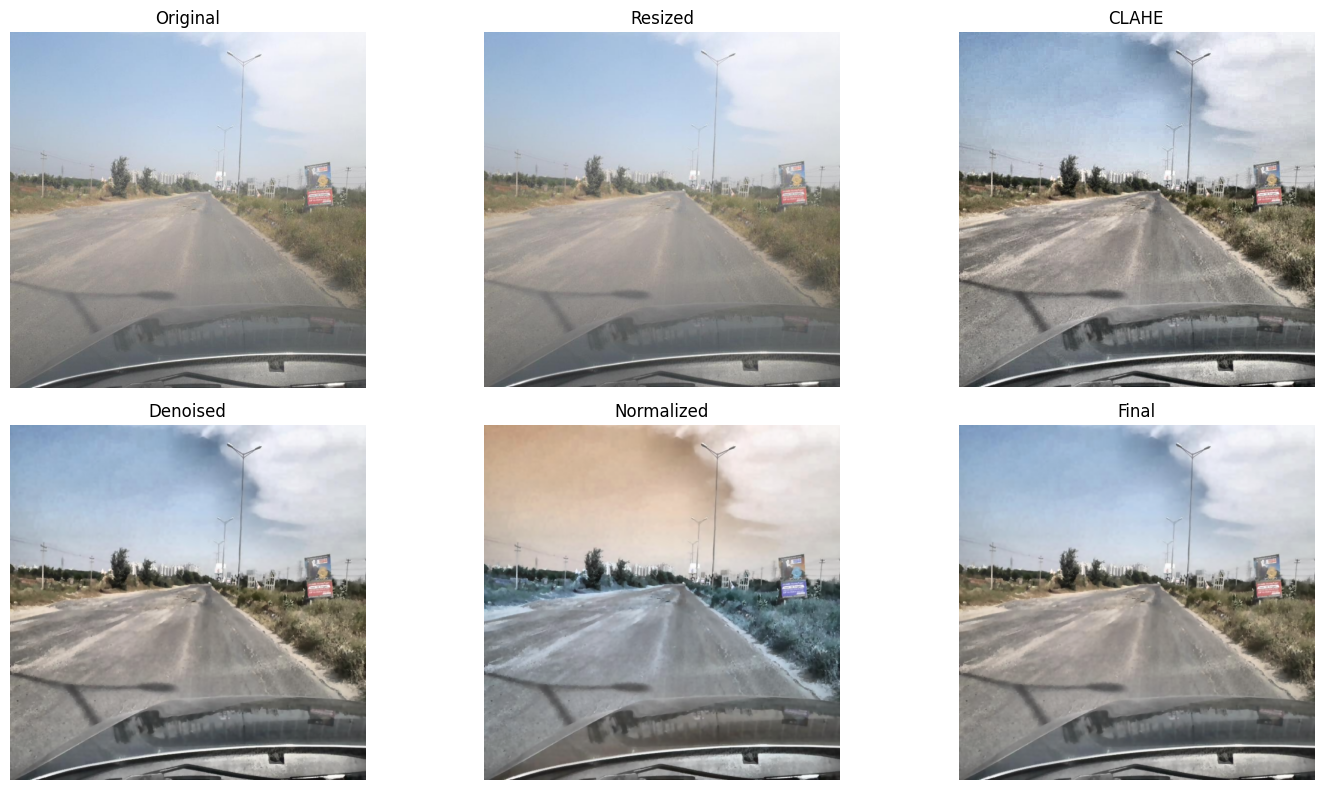

In [50]:
debug_sample = next(sample for sample in test_samples)
debug_img_bgr = cv2.imread(Path(debug_sample).absolute())
resized_bgr = resize_image(debug_img_bgr)
clahe_bgr = apply_clahe_bgr(resized_bgr)
denoised_bgr = denoise_image(clahe_bgr)
final_bgr = enhance_for_road_damage(debug_img_bgr)
normalized = normalize_for_display(final_bgr)

plt.figure(figsize=(15, 8))
previews = [
    ("Original", cv2.cvtColor(debug_img_bgr, cv2.COLOR_BGR2RGB)),
    ("Resized", cv2.cvtColor(resized_bgr, cv2.COLOR_BGR2RGB)),
    ("CLAHE", cv2.cvtColor(clahe_bgr, cv2.COLOR_BGR2RGB)),
    ("Denoised", cv2.cvtColor(denoised_bgr, cv2.COLOR_BGR2RGB)),
    ("Normalized", normalized),
    ("Final", cv2.cvtColor(final_bgr, cv2.COLOR_BGR2RGB)),
]

for idx, (title, image) in enumerate(previews, start=1):
    plt.subplot(2, 3, idx)
    plt.imshow(image, cmap=None)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()
    

In [51]:
splits = ["train", "val", "test"]


In [ ]:
def export_yolo_split(
    image_paths,
    split_name,
    *,
    src_root=DATASET_DIR,
    dst_root=PREPROCESSED_DIR,
):
    """Write enhanced square images and copy YOLO labels from an existing split.

    ``image_paths`` should be paths under ``src_root / split_name / images``
    (as returned by ``Path.glob``). Labels are read from the matching
    ``labels/*.txt`` files. Normalized YOLO ``cx cy w h`` stay valid after
    ``cv2.resize`` to ``(IMG_SIZE, IMG_SIZE)`` because x and y scale independently.
    """
    src_label_dir = src_root / split_name / "labels"
    dst_image_dir = dst_root / split_name / "images"
    dst_label_dir = dst_root / split_name / "labels"
    dst_image_dir.mkdir(parents=True, exist_ok=True)
    dst_label_dir.mkdir(parents=True, exist_ok=True)

    for image_path in tqdm(image_paths, desc=f"Exporting {split_name}"):
        image_path = Path(image_path)
        image_bgr = cv2.imread(str(image_path))
        if image_bgr is None:
            continue
        processed = enhance_for_road_damage(image_bgr)
        cv2.imwrite(str(dst_image_dir / image_path.name), processed)

        label_src = src_label_dir / f"{image_path.stem}.txt"
        label_text = ""
        if label_src.exists():
            label_text = label_src.read_text(encoding="utf-8").strip()
        (dst_label_dir / f"{image_path.stem}.txt").write_text(
            (label_text + "\n") if label_text else "",
            encoding="utf-8",
        )


In [ ]:
# Example: export every split into PREPROCESSED_DIR (train as-is — edit if you only want samples)
for split in splits:
    paths = sorted((DATASET_DIR / split / "images").glob("*.jpg"))
    export_yolo_split(paths, split)


Exporting test: 100%|██████████| 3543/3543 [01:24<00:00, 41.89it/s]


../../../datasets/RD2022/test/images/United_States_002621.jpg ../../../datasets/RD2022_preprocessed/test/images/United_States_002621.jpg


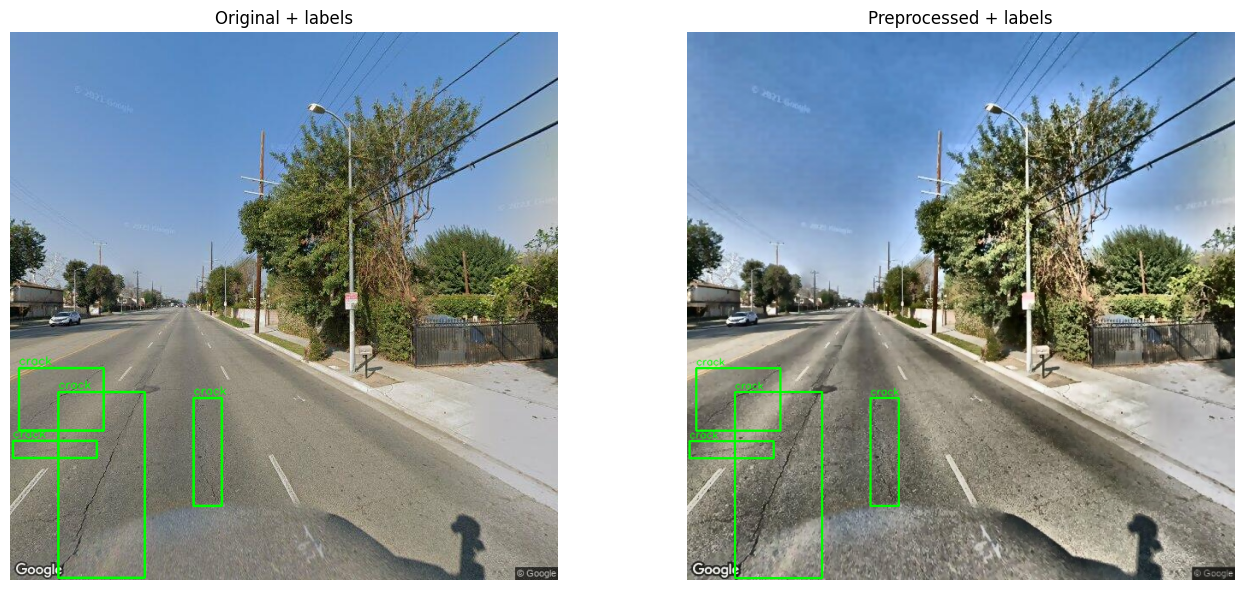

../../../datasets/RD2022/test/images/Japan_003899.jpg ../../../datasets/RD2022_preprocessed/test/images/Japan_003899.jpg


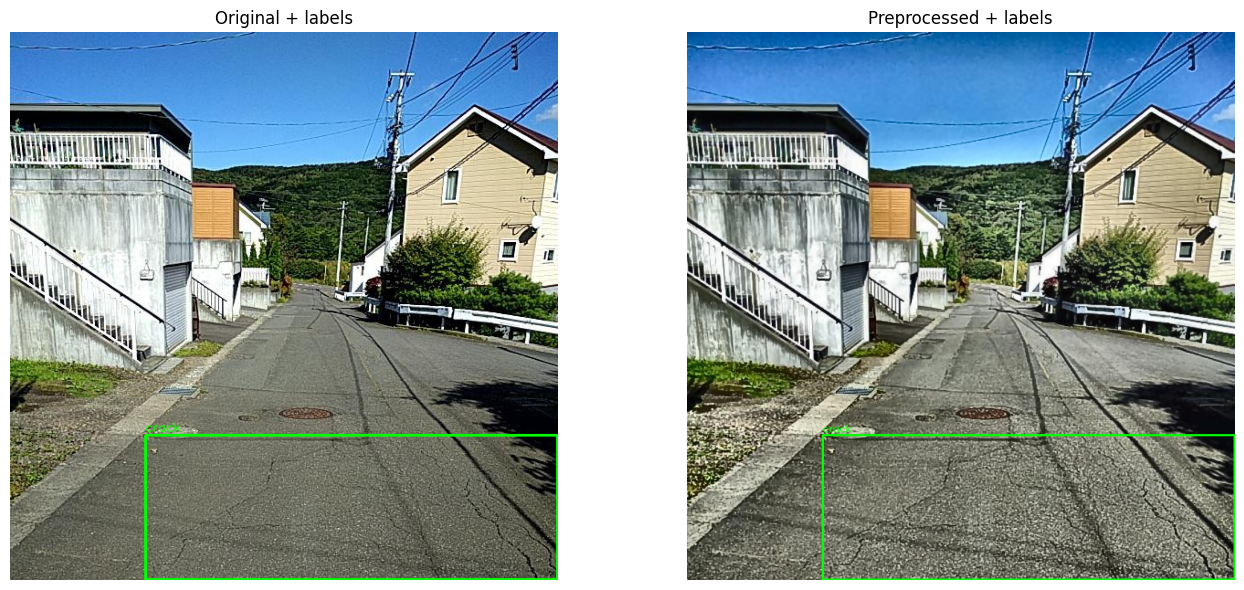

../../../datasets/RD2022/test/images/United_States_004361.jpg ../../../datasets/RD2022_preprocessed/test/images/United_States_004361.jpg


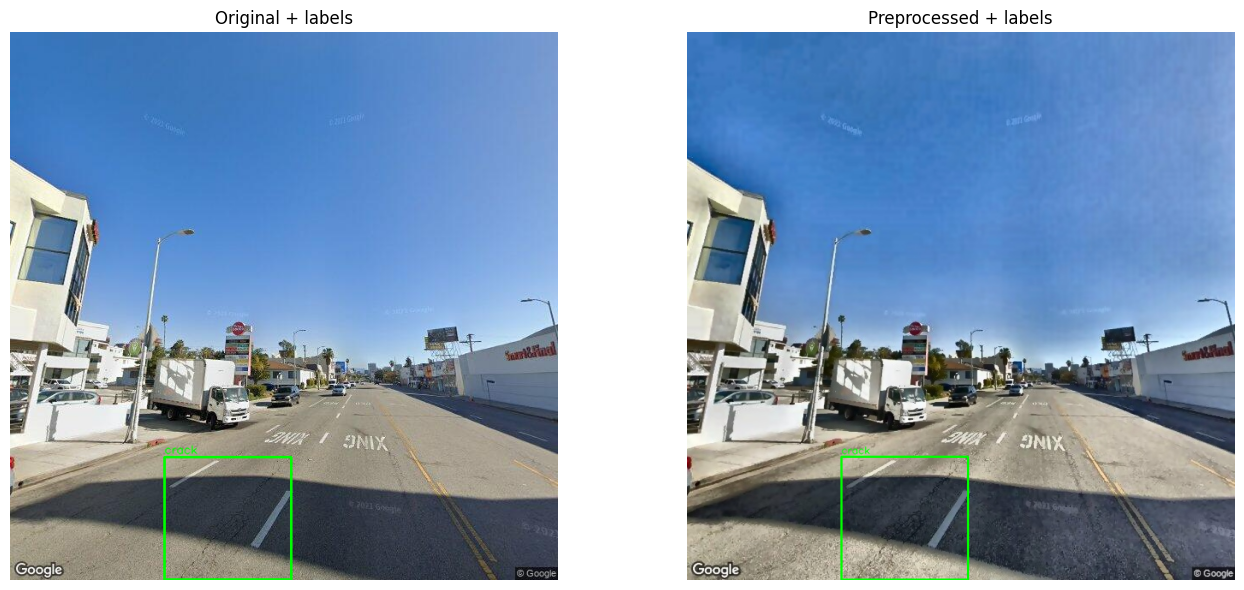

../../../datasets/RD2022/test/images/Japan_011412.jpg ../../../datasets/RD2022_preprocessed/test/images/Japan_011412.jpg


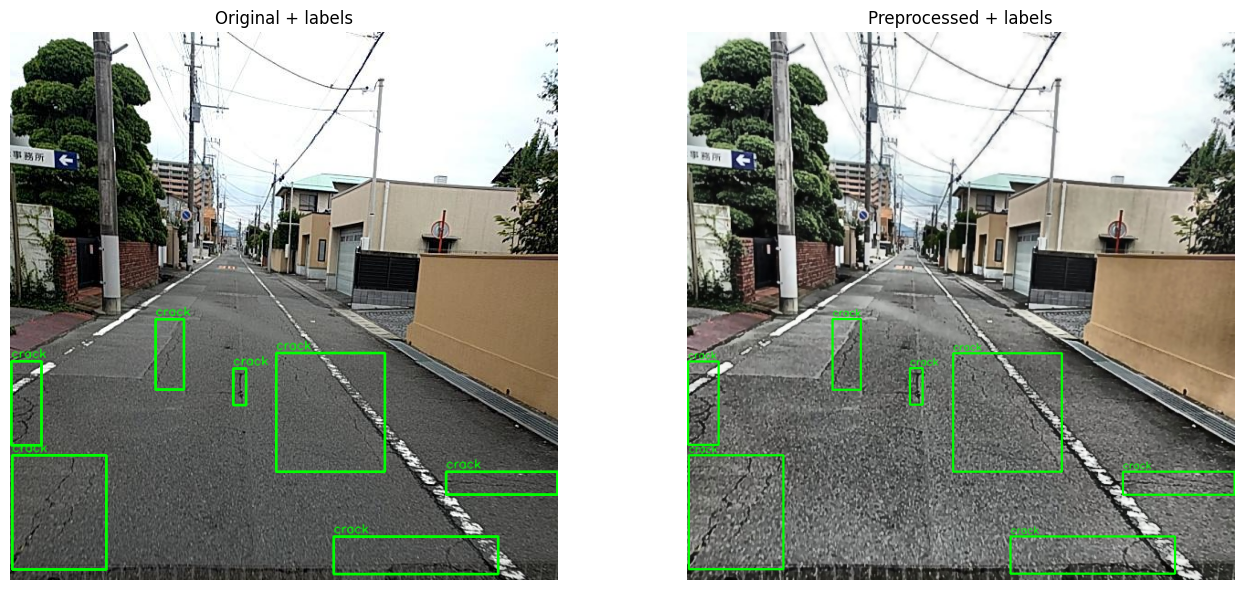

../../../datasets/RD2022/test/images/Japan_009669.jpg ../../../datasets/RD2022_preprocessed/test/images/Japan_009669.jpg


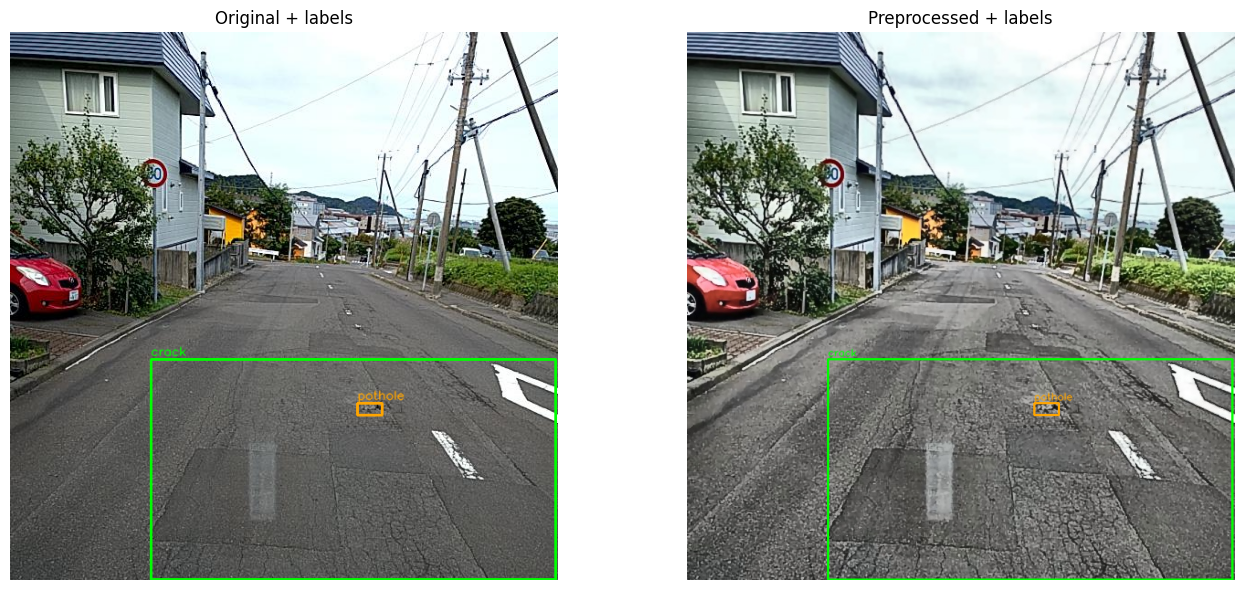

In [73]:
# Compare preprocessed to original (with YOLO boxes)
train_images = list((DATASET_DIR / "train/images").glob("*.jpg"))
val_images = list((DATASET_DIR / "val/images").glob("*.jpg"))
test_images = list((DATASET_DIR / "test/images").glob("*.jpg"))

train_samples = random.sample(train_images, 5)
val_samples = random.sample(val_images, 5)
test_samples = random.sample(test_images, 5)


dir_to_test = 'test'


def draw_yolo_on_bgr(img_bgr, label_path):
    """Overlay YOLO xywh boxes (normalized to this image's width/height)."""
    if img_bgr is None:
        return None
    out = img_bgr.copy()
    ih, iw = out.shape[:2]
    id_to_name = {v: k for k, v in CLASS_MAP.items()}
    colors_bgr = {
        0: (0, 255, 0),
        1: (0, 165, 255),
    }
    if not label_path.exists():
        return out
    for line in label_path.read_text(encoding="utf-8").splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cid = int(float(parts[0]))
        cx, cy, bw, bh = map(float, parts[1:])
        x1 = int(round((cx - bw / 2) * iw))
        y1 = int(round((cy - bh / 2) * ih))
        x2 = int(round((cx + bw / 2) * iw))
        y2 = int(round((cy + bh / 2) * ih))
        x1, x2 = sorted((max(0, x1), min(iw - 1, x2)))
        y1, y2 = sorted((max(0, y1), min(ih - 1, y2)))
        color = colors_bgr.get(cid, (255, 255, 255))
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
        name = id_to_name.get(cid, str(cid))
        cv2.putText(
            out,
            name,
            (x1, max(y1 - 4, 12)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            color,
            1,
            cv2.LINE_AA,
        )
    return out



for image in test_samples:
    image_name = Path(image).name
    stem = Path(image_name).stem

    org_path = DATASET_DIR / f"{dir_to_test}/images" / image_name
    prsd_path = PREPROCESSED_DIR / f"{dir_to_test}/images" / image_name
    label_path = DATASET_DIR / f"{dir_to_test}/labels" / f"{stem}.txt"

    print(org_path, prsd_path)

    org_image = cv2.imread(str(org_path))
    prsd_image = cv2.imread(str(prsd_path))

    org_drawn = draw_yolo_on_bgr(org_image, label_path)
    prsd_drawn = draw_yolo_on_bgr(prsd_image, label_path)

    plt.figure(figsize=(14, 6))
    previews = [
        ("Original + labels", cv2.cvtColor(org_drawn, cv2.COLOR_BGR2RGB)),
        ("Preprocessed + labels", cv2.cvtColor(prsd_drawn, cv2.COLOR_BGR2RGB)),
    ]

    for idx, (title, rgb) in enumerate(previews, start=1):
        plt.subplot(1, 2, idx)
        plt.imshow(rgb)
        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()
